# <b><i><u>mental_health_status_model_building </u>----</b></i>

In [1]:
# FOR PATH RECOGNISION ----

from pathlib import Path

print("Current Folder:")
print(Path.cwd())

print("\nParent:")
print(Path.cwd().parent)

Current Folder:
c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\mental_health_dataset

Parent:
c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks


In [2]:
# IGNORE WARNING --

import warnings

warnings.filterwarnings("ignore")

In [3]:
# IMPORTING ALL THE NECESSARY LIBRARIES --

# Data Handling

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler
)

# Train Test Split

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

# Models

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from xgboost import (
    XGBClassifier,
    XGBRegressor
)

# Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model Saving

import joblib

# Display

pd.set_option(
    "display.max_columns",
    None
)

sns.set_style("whitegrid")

print("all the necessary libraries are imported sucessfully:")
print("🎉🎉🎉🎉")

all the necessary libraries are imported sucessfully:
🎉🎉🎉🎉


In [5]:
# loading dataset --

# current folder = Calmify_AI/notebooks/mental_health_status
CURRENT_DIR = Path.cwd()

# notebooks folder
NOTEBOOKS_DIR = CURRENT_DIR.parent

# preprocessed file path
DATA_PATH = NOTEBOOKS_DIR / "preprocessed" / "mental_health_feature_engineered.csv"

print("Current Dir :", CURRENT_DIR)
print("Notebooks Dir:", NOTEBOOKS_DIR)
print("Data Path   :", DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Current Dir : c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\mental_health_dataset
Notebooks Dir: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks
Data Path   : c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\preprocessed\mental_health_feature_engineered.csv
Dataset loaded successfully
Shape: (500, 24)


,age,gender,gpa,stress_level,anxiety_score,depression_score,sleep_hours,steps_per_day,mood_description,sentiment_score,mental_health_status,reflection_word_count,reflection_char_count,positive_word_count,negative_word_count,stress_word_count,emotional_distress_score,sleep_deficit,activity_score,gpa_risk,mood_score,reflection_sentiment_balance,overall_mental_risk_score,mood_description_encoded
0,23,2,2.52,5,20,6,6.8,4166,Happy,0.0000,2,8,58,0,0,0,10.333333,1.2,4.166,1.48,2.0,0,8.268,1
1,19,1,2.74,5,3,7,5.1,4949,Tired,0.4678,2,8,51,0,0,0,5.000000,2.9,4.949,1.26,-1.0,0,4.416,6
2,21,0,3.53,5,11,24,8.3,7632,Sad,0.5106,2,12,76,0,0,0,13.333333,0.0,7.632,0.47,-2.0,0,10.297,4
3,18,1,2.04,4,15,14,8.2,5548,Sad,0.2960,2,7,39,0,0,0,11.000000,0.0,5.548,1.96,-2.0,0,8.646,4
4,19,2,2.87,1,2,4,5.9,3698,Happy,0.4588,0,16,107,0,0,0,2.333333,2.1,3.698,1.13,2.0,0,2.123,1


# <B><I><U>TARGET DISTRIBUTION </U> ----</B></I>

In [7]:
# target distribution --

df["mental_health_status"].value_counts().sort_index()

target_dist = df["mental_health_status"].value_counts(normalize=True) * 100
target_dist.sort_index()

mental_health_status
0     4.4
1    27.4
2    68.2
Name: proportion, dtype: float64

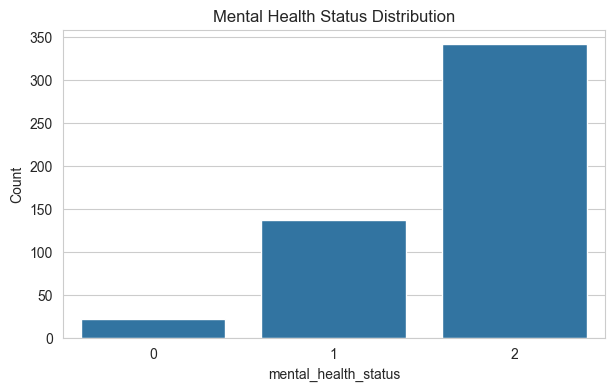

In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="mental_health_status")
plt.title("Mental Health Status Distribution")
plt.xlabel("mental_health_status")
plt.ylabel("Count")
plt.show()

In [9]:
# DEFINING FEATURES AND TARGET --

TARGET = "mental_health_status"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 23)
y shape: (500,)


# <B><U><I>CORRELATION </U> -----</B></I>

In [10]:
# WITH TARGET --

corr_with_target = df.corr(numeric_only=True)[TARGET].sort_values(ascending=False)

corr_with_target

mental_health_status            1.000000
overall_mental_risk_score       0.682400
emotional_distress_score        0.679612
depression_score                0.555785
anxiety_score                   0.380979
stress_level                    0.258021
gpa                             0.079684
mood_description_encoded        0.065702
sleep_deficit                   0.036971
positive_word_count             0.035346
reflection_sentiment_balance    0.035346
age                             0.031575
sentiment_score                 0.012312
reflection_char_count           0.007723
reflection_word_count           0.002656
mood_score                     -0.007377
steps_per_day                  -0.021148
activity_score                 -0.021148
stress_word_count              -0.026929
gender                         -0.035519
sleep_hours                    -0.036386
gpa_risk                       -0.079684
negative_word_count                  NaN
Name: mental_health_status, dtype: float64

In [11]:
corr_features = corr_with_target.drop(TARGET, errors="ignore")
corr_features

overall_mental_risk_score       0.682400
emotional_distress_score        0.679612
depression_score                0.555785
anxiety_score                   0.380979
stress_level                    0.258021
gpa                             0.079684
mood_description_encoded        0.065702
sleep_deficit                   0.036971
positive_word_count             0.035346
reflection_sentiment_balance    0.035346
age                             0.031575
sentiment_score                 0.012312
reflection_char_count           0.007723
reflection_word_count           0.002656
mood_score                     -0.007377
steps_per_day                  -0.021148
activity_score                 -0.021148
stress_word_count              -0.026929
gender                         -0.035519
sleep_hours                    -0.036386
gpa_risk                       -0.079684
negative_word_count                  NaN
Name: mental_health_status, dtype: float64

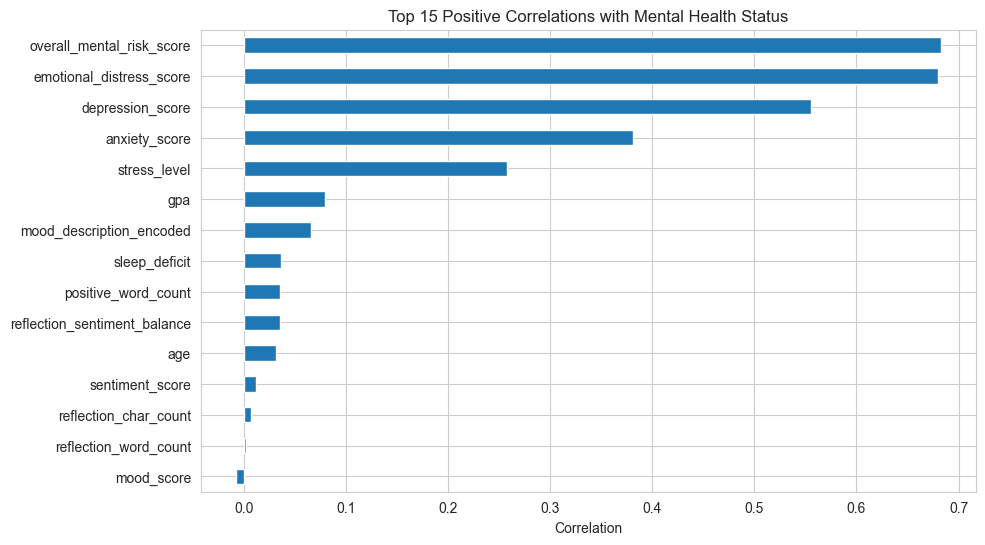

In [12]:
# TOP CORRELATED FEATURES --

top_n = 15

plt.figure(figsize=(10, 6))
corr_features.head(top_n).sort_values().plot(kind="barh")
plt.title(f"Top {top_n} Positive Correlations with Mental Health Status")
plt.xlabel("Correlation")
plt.show()

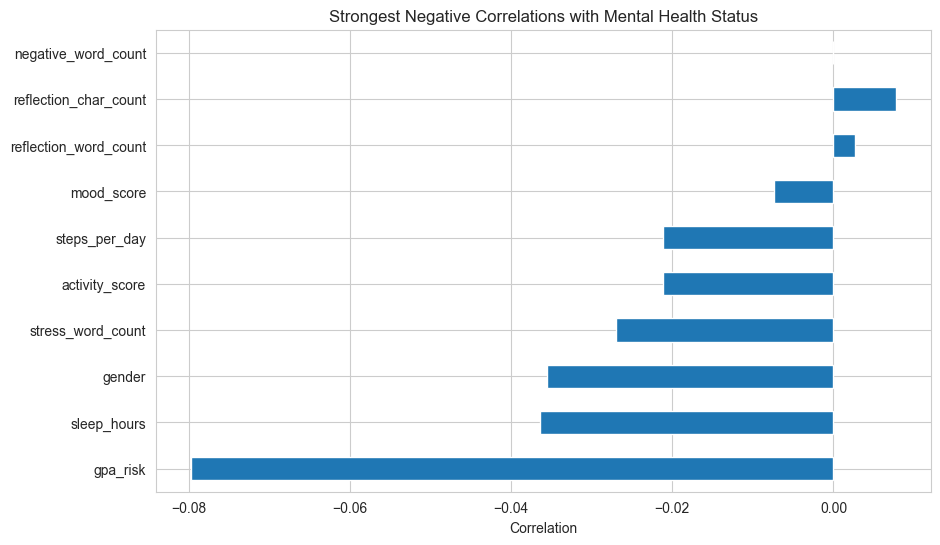

In [13]:
# STRONG NEGATIVE FEATURES --

plt.figure(figsize=(10, 6))
corr_features.tail(10).sort_values().plot(kind="barh")
plt.title("Strongest Negative Correlations with Mental Health Status")
plt.xlabel("Correlation")
plt.show()

In [14]:
# SELECTED FEATURES --

selected_features = [
    # core mental health
    "stress_level",
    "anxiety_score",
    "depression_score",
    "sentiment_score",
    "mood_score",
    "mood_description_encoded",

    # sleep / activity / academic
    "sleep_hours",
    "sleep_deficit",
    "steps_per_day",
    "activity_score",
    "gpa",
    "gpa_risk",

    # reflection / text engineered
    "positive_word_count",
    "negative_word_count",
    "stress_word_count",
    "reflection_word_count",
    "reflection_sentiment_balance",

    # combined engineered scores
    "emotional_distress_score",
    "overall_mental_risk_score",

    # demographic
    "age",
    "gender"
]

In [15]:
selected_features = [col for col in selected_features if col in X.columns]

print("Selected feature count:", len(selected_features))
print(selected_features)

Selected feature count: 21
['stress_level', 'anxiety_score', 'depression_score', 'sentiment_score', 'mood_score', 'mood_description_encoded', 'sleep_hours', 'sleep_deficit', 'steps_per_day', 'activity_score', 'gpa', 'gpa_risk', 'positive_word_count', 'negative_word_count', 'stress_word_count', 'reflection_word_count', 'reflection_sentiment_balance', 'emotional_distress_score', 'overall_mental_risk_score', 'age', 'gender']


In [16]:
X_selected = X[selected_features].copy()

print("X_selected shape:", X_selected.shape)
X_selected.head()

X_selected shape: (500, 21)


,stress_level,anxiety_score,depression_score,sentiment_score,mood_score,mood_description_encoded,sleep_hours,sleep_deficit,steps_per_day,activity_score,gpa,gpa_risk,positive_word_count,negative_word_count,stress_word_count,reflection_word_count,reflection_sentiment_balance,emotional_distress_score,overall_mental_risk_score,age,gender
0,5,20,6,0.0000,2.0,1,6.8,1.2,4166,4.166,2.52,1.48,0,0,0,8,0,10.333333,8.268,23,2
1,5,3,7,0.4678,-1.0,6,5.1,2.9,4949,4.949,2.74,1.26,0,0,0,8,0,5.000000,4.416,19,1
2,5,11,24,0.5106,-2.0,4,8.3,0.0,7632,7.632,3.53,0.47,0,0,0,12,0,13.333333,10.297,21,0
3,4,15,14,0.2960,-2.0,4,8.2,0.0,5548,5.548,2.04,1.96,0,0,0,7,0,11.000000,8.646,18,1
4,1,2,4,0.4588,2.0,1,5.9,2.1,3698,3.698,2.87,1.13,0,0,0,16,0,2.333333,2.123,19,2


# <B><I><U>MODEL BUILDING </U>----</B></I>

In [17]:
# TRAIN TEST SPLIT --

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (400, 21)
X_test shape : (100, 21)
y_train shape: (400,)
y_test shape : (100,)


# <B><I><U>MODEL 1 </U>----<B><I>

In [19]:
# LOGISTIC REGRESSION MODEL --

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)

In [20]:
# EVALUATION --

log_acc = accuracy_score(y_test, log_preds)
log_f1 = f1_score(y_test, log_preds, average="weighted")

print("Logistic Regression Accuracy :", round(log_acc * 100, 2), "%")
print("Logistic Regression F1 Score :", round(log_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, log_preds))

Logistic Regression Accuracy : 80.0 %
Logistic Regression F1 Score : 0.7986

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.40      0.50         5
           1       0.62      0.67      0.64        27
           2       0.88      0.88      0.88        68

    accuracy                           0.80       100
   macro avg       0.72      0.65      0.68       100
weighted avg       0.80      0.80      0.80       100



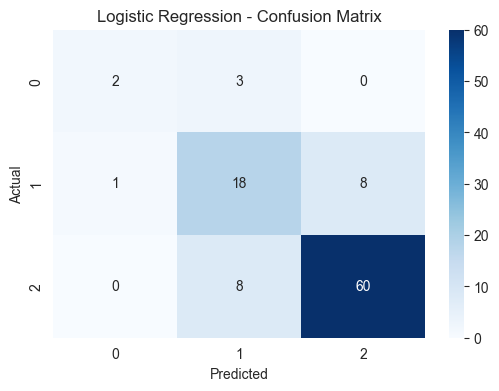

In [21]:
# CORRELATION MATRIX --

cm = confusion_matrix(y_test, log_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# <B><U><I>MODEL 2 </U>----</B></I>

In [22]:
# RANDOM FOREST --

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [23]:
# EVALUATION --

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds, average="weighted")

print("Random Forest Accuracy :", round(rf_acc * 100, 2), "%")
print("Random Forest F1 Score :", round(rf_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_preds))

Random Forest Accuracy : 96.0 %
Random Forest F1 Score : 0.9543

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.90      0.96      0.93        27
           2       0.99      1.00      0.99        68

    accuracy                           0.96       100
   macro avg       0.96      0.79      0.83       100
weighted avg       0.96      0.96      0.95       100



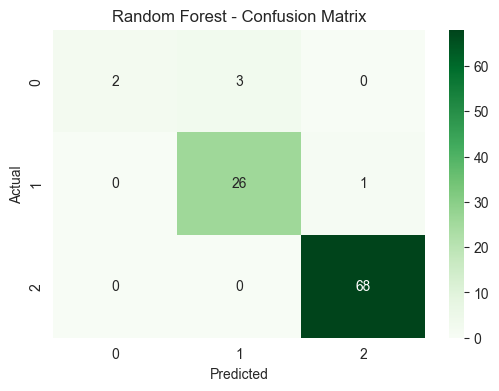

In [24]:
# CONFUSION MATRIX --

cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# <B><U><I>MODEL 3 </U>----</B></I>

In [25]:
# XGBOOST --

num_classes = y.nunique()
print("Number of target classes:", num_classes)
print("Classes:", sorted(y.unique()))

Number of target classes: 3
Classes: [np.int64(0), np.int64(1), np.int64(2)]


In [26]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softmax",
    num_class=num_classes,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

In [27]:
# EVALUATION --

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds, average="weighted")

print("XGBoost Accuracy :", round(xgb_acc * 100, 2), "%")
print("XGBoost F1 Score :", round(xgb_f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_preds))

XGBoost Accuracy : 100.0 %
XGBoost F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        68

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



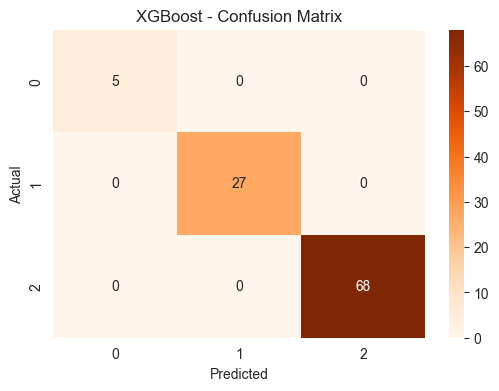

In [28]:
# CONFUSION MATRIX --

cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
# MODEL COMPARISON --

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        log_acc,
        rf_acc,
        xgb_acc
    ],
    "Weighted_F1": [
        log_f1,
        rf_f1,
        xgb_f1
    ]
})

results = results.sort_values(
    by=["Weighted_F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Weighted_F1
0,XGBoost,1.00,1.000000
1,Random Forest,0.96,0.954322
2,Logistic Regression,0.80,0.798571


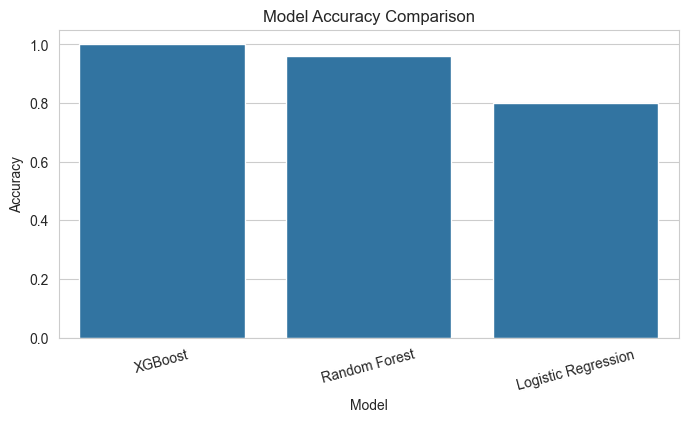

In [31]:
# VISUAL COMPARISON --

plt.figure(figsize=(8, 4))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()


In [32]:
# SAVING MODEL --

# current notebook folder
CURRENT_DIR = Path.cwd()

# notebooks folder
NOTEBOOKS_DIR = CURRENT_DIR.parent

# notebooks/models folder
MODELS_DIR = NOTEBOOKS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_save_path = MODELS_DIR / "mental_health_status_model_v1.pkl"
joblib.dump(xgb_model, model_save_path)

print("Mental health status model saved successfully")
print("Saved at:", model_save_path)

Mental health status model saved successfully
Saved at: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\models\mental_health_status_model_v1.pkl


In [33]:
# SAVING FEATURES --

feature_names = X.columns.tolist()

feature_save_path = MODELS_DIR / "mental_health_status_features_v1.pkl"
joblib.dump(feature_names, feature_save_path)

print("Mental health feature list saved successfully")
print("Saved at:", feature_save_path)
print(feature_names)

Mental health feature list saved successfully
Saved at: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\models\mental_health_status_features_v1.pkl
['age', 'gender', 'gpa', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'steps_per_day', 'mood_description', 'sentiment_score', 'reflection_word_count', 'reflection_char_count', 'positive_word_count', 'negative_word_count', 'stress_word_count', 'emotional_distress_score', 'sleep_deficit', 'activity_score', 'gpa_risk', 'mood_score', 'reflection_sentiment_balance', 'overall_mental_risk_score', 'mood_description_encoded']


In [34]:
print("hogaya:😁😁")

hogaya:😁😁
